In [8]:
# ============================================================
# SETUP: Install and import required libraries
# ============================================================
!pip install -q tensorflow tensorflow-datasets
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import os
import pandas as pd
from PIL import Image
import kagglehub
import cv2
import glob
from sklearn.model_selection import train_test_split

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
# ============================================================
# Keras 3.x compatibility helper
# ============================================================
def get_layer_shape(layer):
    """Get output shape compatible with both Keras 2.x and 3.x."""
    try:
        return layer.output_shape
    except AttributeError:
        return layer.output.shape

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [9]:
# ============================================================
# CONFIGURATION
# ============================================================
IMG_SIZE = 256
BATCH_SIZE = 16
BUFFER_SIZE = 1000
EPOCHS_FULL = 50 # For full U-Net training
CLASS_NAMES = ["Dry", "Flood"]
NUM_CLASSES = 2 #

## Data Loading

In [10]:
# Download latest version
path = kagglehub.dataset_download("faizalkarim/flood-area-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flood-area-segmentation' dataset.
Path to dataset files: /kaggle/input/flood-area-segmentation


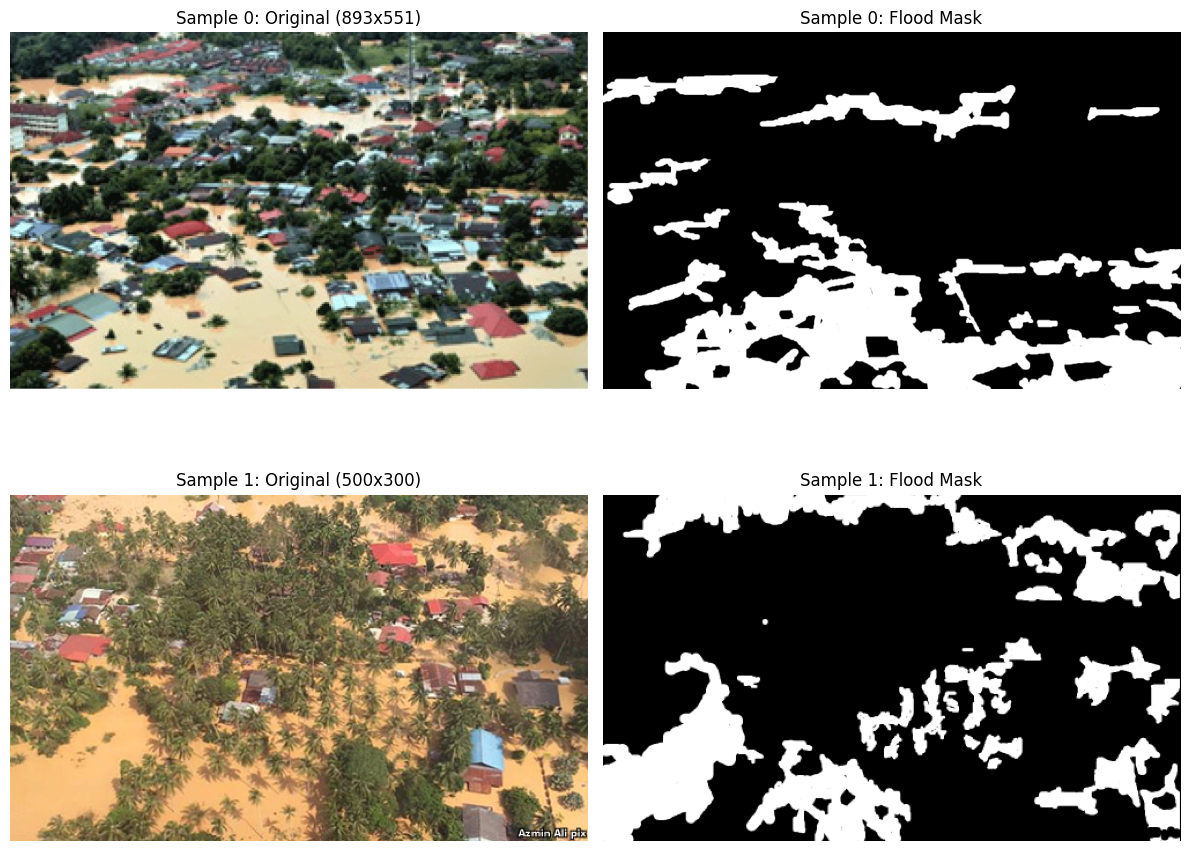

In [11]:
# Use the 'path' from your kagglehub download
data_dir = path 

image_folder = os.path.join(data_dir, 'Image')
mask_folder = os.path.join(data_dir, 'Mask')

# Get a list of file names
image_files = sorted(os.listdir(image_folder))
mask_files = sorted(os.listdir(mask_folder))
image_paths = sorted(glob.glob(os.path.join(image_folder, "*.jpg")))
mask_paths = sorted(glob.glob(os.path.join(mask_folder, "*.png")))

# Define the two indices you want to inspect
sample_indices = [0, 1] 

# Create a 2-row, 2-column grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, idx in enumerate(sample_indices):
    # Load Image and Mask
    img = Image.open(image_paths[idx])
    mask = Image.open(mask_paths[idx])
    
    # Get dimensions
    w, h = img.size
    
    # Plot Original Image on the left
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Sample {idx}: Original ({w}x{h})")
    axes[i, 0].axis('off')
    
    # Plot Mask on the right
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f"Sample {idx}: Flood Mask")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

Image Size is random

In [12]:
metaDf = pd.read_csv(path+"/metadata.csv")
metaDf.head()

,Image,Mask
0,0.jpg,0.png
1,1.jpg,1.png
2,2.jpg,2.png
3,3.jpg,3.png
4,4.jpg,4.png


## Class Distribution

In [13]:
total_flood_pixels = 0
total_pixels = 0

for m_name in mask_files:
    mask = cv2.imread(os.path.join(mask_folder, m_name), cv2.IMREAD_GRAYSCALE)
    
    # Binary threshold (ensure 0 and 1)
    binary_mask = np.where(mask > 127, 1, 0)
    
    total_flood_pixels += np.sum(binary_mask)
    total_pixels += binary_mask.size

flood_percentage = (total_flood_pixels / total_pixels) * 100
dry_percentage = 100 - flood_percentage

print(f"Dry Pixels: {dry_percentage:.2f}%")
print(f"Flood Pixels: {flood_percentage:.2f}%")


Dry Pixels: 54.41%
Flood Pixels: 45.59%


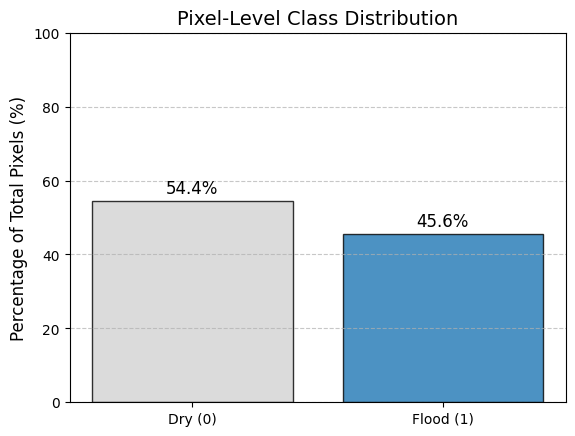

In [14]:
labels = ['Dry (0)', 'Flood (1)']
percentages = [dry_percentage, flood_percentage]
colors = ['#d3d3d3', '#1f77b4']  # Light gray and Blue

plt.figure()
bars = plt.bar(labels, percentages, color=colors, edgecolor='black', alpha=0.8)

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=12)

plt.title('Pixel-Level Class Distribution', fontsize=14)
plt.ylabel('Percentage of Total Pixels (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Preprocessing 

(Train/Validation Split + Normalization + Augmentation)

In [15]:
# Verification check
print(f"Total verified images: {len(image_files)}")
print(f"Total verified masks: {len(mask_files)}")

# Perform the Split (80% Train, 20% Validation)
train_img, val_img, train_msk, val_msk = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

print(f"Training on: {len(train_img)}")
print(f"Validating on: {len(val_img)}")

Total verified images: 290
Total verified masks: 290
Training on: 232
Validating on: 58


In [16]:
# Define output directories
base_out = '/kaggle/working/clean_data'
img_out = os.path.join(base_out, 'images')
msk_out = os.path.join(base_out, 'masks')
os.makedirs(img_out, exist_ok=True)
os.makedirs(msk_out, exist_ok=True)

def standardize_and_save(img_list, msk_list):
    new_img_paths = []
    new_msk_paths = []
    
    print(f"Standardizing {len(img_list)} pairs...")
    
    for i, m in zip(img_list, msk_list):
        img_name = os.path.splitext(os.path.basename(i))[0] + ".jpg"
        msk_name = os.path.splitext(os.path.basename(m))[0] + ".png"
        
        target_img_path = os.path.join(img_out, img_name)
        target_msk_path = os.path.join(msk_out, msk_name)
        
        try:
            # 1. Standardize Image to RGB JPEG
            with Image.open(i) as img:
                img.convert('RGB').save(target_img_path, "JPEG", quality=95)
            
            # 2. Standardize Mask to Grayscale PNG
            with Image.open(m) as msk:
                msk.convert('L').save(target_msk_path, "PNG")
                
            new_img_paths.append(target_img_path)
            new_msk_paths.append(target_msk_path)
            
        except Exception as e:
            print(f"Failed to convert {img_name}: {e}")
            
    print(f"Done! {len(new_img_paths)} pairs ready in {base_out}")
    return new_img_paths, new_msk_paths

# Convert both sets
train_img, train_msk = standardize_and_save(train_img, train_msk)
val_img, val_msk = standardize_and_save(val_img, val_msk)

Standardizing 232 pairs...
Done! 232 pairs ready in /kaggle/working/clean_data
Standardizing 58 pairs...
Done! 58 pairs ready in /kaggle/working/clean_data


In [17]:
def process_path(image_path, mask_path):
    # Load Image (Must be JPEG)
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  

    # Load Mask (Must be PNG)
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize_with_pad(mask, IMG_SIZE, IMG_SIZE)
    mask = tf.cast(mask > 127, tf.float32) 
    
    # Explicitly set shapes for the Keras graph
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])
    
    return img, mask

def augment(image, mask):
    """Apply random augmentations to image and mask together."""
    # Random horizontal flip (apply to BOTH image and mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)
    # Random vertical flip (apply to BOTH image and mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)
    # Random brightness and contrast (image ONLY, not mask!)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, mask

# Build the Dataset
# TRAINING DATASET
train_ds = tf.data.Dataset.from_tensor_slices((train_img, train_msk))
train_ds = train_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.cache().map(augment).shuffle(100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# VALIDATION DATASET
val_ds = tf.data.Dataset.from_tensor_slices((val_img, val_msk))
val_ds = val_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

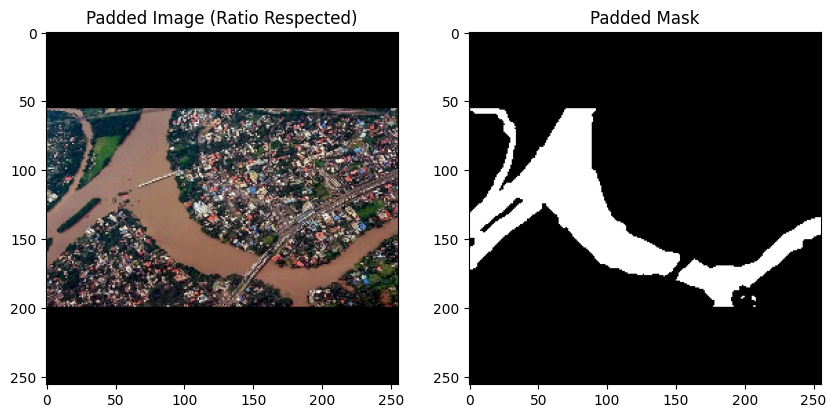

In [18]:
for img, msk in val_ds.take(1):
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img[0])
    plt.title("Padded Image (Ratio Respected)")
    
    plt.subplot(1, 2, 2)
    plt.imshow(msk[0].numpy().squeeze(), cmap='gray')
    plt.title("Padded Mask")
    
    plt.show()
    break

#### View Sample Aumentation

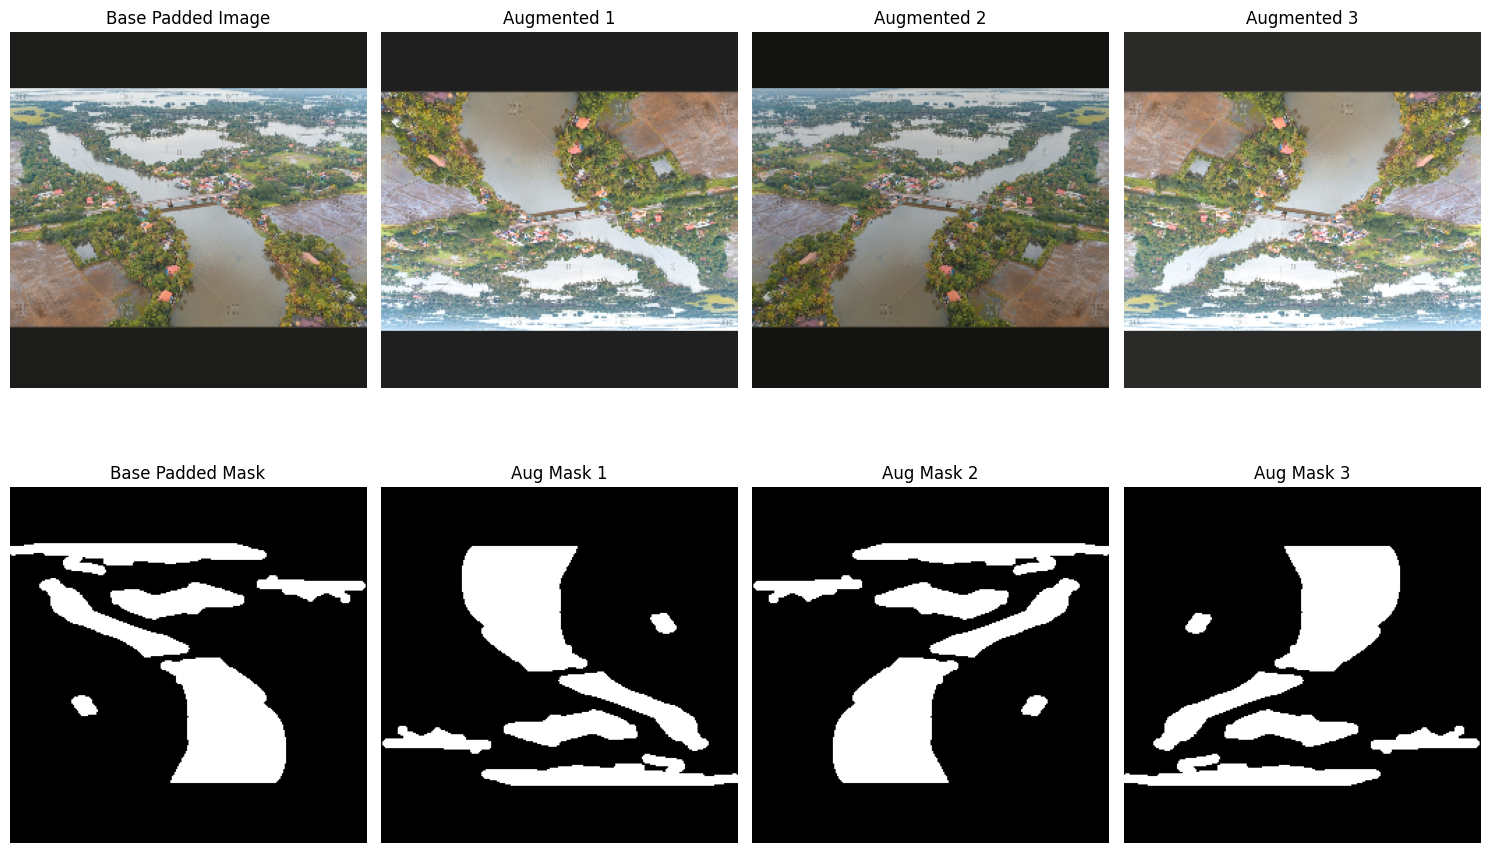

In [19]:
# Grab one batch from the training dataset
for images, masks in train_ds.take(1):
    # Take the very first image/mask pair from the batch
    sample_img = images[0]
    sample_msk = masks[0]

    plt.figure(figsize=(15, 10))

    # Plot the "Original" (though it's already processed/padded)
    plt.subplot(2, 4, 1)
    plt.imshow(sample_img)
    plt.title("Base Padded Image")
    plt.axis('off')

    plt.subplot(2, 4, 5)
    plt.imshow(sample_msk.numpy().squeeze(), cmap='gray')
    plt.title("Base Padded Mask")
    plt.axis('off')

    # Generate 3 augmented versions
    for i in range(3):
        aug_img, aug_msk = augment(sample_img, sample_msk)

        # Plot Augmented Image
        plt.subplot(2, 4, i + 2)
        plt.imshow(aug_img)
        plt.title(f"Augmented {i+1}")
        plt.axis('off')

        # Plot Augmented Mask
        plt.subplot(2, 4, i + 6)
        plt.imshow(aug_msk.numpy().squeeze(), cmap='gray')
        plt.title(f"Aug Mask {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    break

# Model

In [26]:
def encoder_block(inputs, num_filters):
    """Encoder block: Conv2D → BN → ReLU → Conv2D → BN → ReLU → MaxPool.
    Returns: skip connection output AND pooled output."""
    x = layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    skip = x # Save for skip connection BEFORE pooling
    pool = layers.MaxPooling2D(2)(x)
    return skip, pool

def decoder_block(inputs, skip, num_filters):
    """Decoder block: UpConv → Concatenate(skip) → Conv2D → BN → ReLU → Conv2D -> BN → ReLU."""
    x = layers.Conv2DTranspose(num_filters, 2, strides=2,padding='same')(inputs)
    x = layers.Concatenate()([x, skip]) # Skip connection!
    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def bottleneck_block(inputs, num_filters):
    """Bottleneck: Conv2D → BN → ReLU → Conv2D → BN → ReLU (no pooling) -> Dropout 0.5."""
    x = layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    return x

print("Building blocks defined: encoder_block, decoder_block, bottleneck_block")


Building blocks defined: encoder_block, decoder_block, bottleneck_block


In [27]:
# Define Dice Loss
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(tf.cast(y_true, tf.float32), [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

In [29]:
def build_full_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3),num_classes=NUM_CLASSES):
    """Full U-Net with 4 encoder/decoder blocks."""
    inputs = layers.Input(shape=input_shape)
    # --- ENCODER ---
    skip1, pool1 = encoder_block(inputs, 32) # 256→128
    skip2, pool2 = encoder_block(pool1, 64) # 128→64
    skip3, pool3 = encoder_block(pool2, 128) # 64→32
    skip4, pool4 = encoder_block(pool3, 256) # Output: 16x16
    # --- BOTTLENECK ---
    b1 = bottleneck_block(pool4, 512)
    # --- DECODER ---
    d4 = decoder_block(b1, skip4, 256) # Input: 16x16 -> Output: 32x32
    d3 = decoder_block(d4, skip3, 128) # YOUR CODE HERE , skip3, 128) # →64
    d2 = decoder_block(d3, skip2, 64) # →128
    d1 = decoder_block(d2, skip1, 32) # →256
    # --- OUTPUT ---
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid',padding='same')(d1)
    model = models.Model(inputs, outputs, name='Full_UNet')
    return model

full_unet = build_full_unet()
full_unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coef, 'accuracy']
)

In [30]:
# full_unet.summary()

In [31]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# Training

In [32]:
print(f"Training Full U-Net for up to {EPOCHS_FULL} epochs...")
print(f"Using augmented training data, {BATCH_SIZE} batch size")
print(f"Early stopping patience: 5 epochs\n")
full_history = full_unet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FULL,
    callbacks=callbacks,
    verbose=1
)

Training Full U-Net for up to 50 epochs...
Using augmented training data, 16 batch size
Early stopping patience: 5 epochs

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5820 - dice_coef: 0.4351 - loss: 0.5652 - val_accuracy: 0.6154 - val_dice_coef: 0.3446 - val_loss: 0.6516 - learning_rate: 1.0000e-04
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 385ms/step - accuracy: 0.7470 - dice_coef: 0.5805 - loss: 0.4197 - val_accuracy: 0.6167 - val_dice_coef: 0.3585 - val_loss: 0.6374 - learning_rate: 1.0000e-04
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 345ms/step - accuracy: 0.7817 - dice_coef: 0.6189 - loss: 0.3814 - val_accuracy: 0.3400 - val_dice_coef: 0.3911 - val_loss: 0.6042 - learning_rate: 1.0000e-04
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 341ms/step - accuracy: 0.8202 - dice_coef: 0.6302 - loss: 0.3701 - val_accuracy: 0.3856 - val_dice_coef: 0.4183 - val_loss: 0.5765 - learning_rate: 1.0000e-04
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 351ms/step - accuracy: 0.8516 - dice

# Evaluation

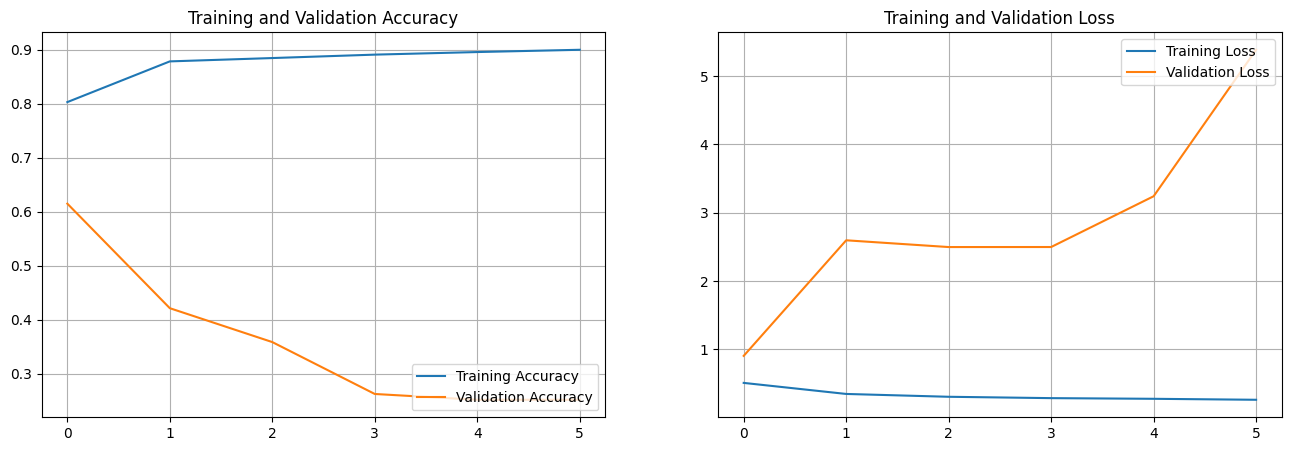

In [25]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.show()

plot_history(full_history)